# 🧠 Neuro Spike Visualizer

An interactive walkthrough for visualizing neuronal spike trains and
analyzing firing rates.

This notebook covers:
1. Loading spike train data from CSV
2. Raster plots
3. Firing rate over time (population rate)
4. Spike count histograms
5. Inter-spike interval (ISI) distributions
6. Comparing firing rates across neurons


In [1]:
import sys
sys.path.append('..')  # so we can import from src/

import matplotlib.pyplot as plt
from src import loader, analysis, visualization

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)


## 1. Load the spike data

In [2]:
spikes = loader.load_spike_csv('../data/sample_spikes.csv')

ids = loader.neuron_ids(spikes)
duration = loader.recording_duration(spikes)

print(f"Neurons found: {ids}")
print(f"Recording duration: {duration:.2f} s")
for nid in ids:
    print(f"  Neuron {nid}: {len(spikes[nid])} spikes")


Neurons found: [1, 2, 3, 4, 5]
Recording duration: 10.00 s
  Neuron 1: 72 spikes
  Neuron 2: 122 spikes
  Neuron 3: 132 spikes
  Neuron 4: 30 spikes
  Neuron 5: 126 spikes


## 2. Raster plot

Each row is a neuron; each tick mark is a spike.

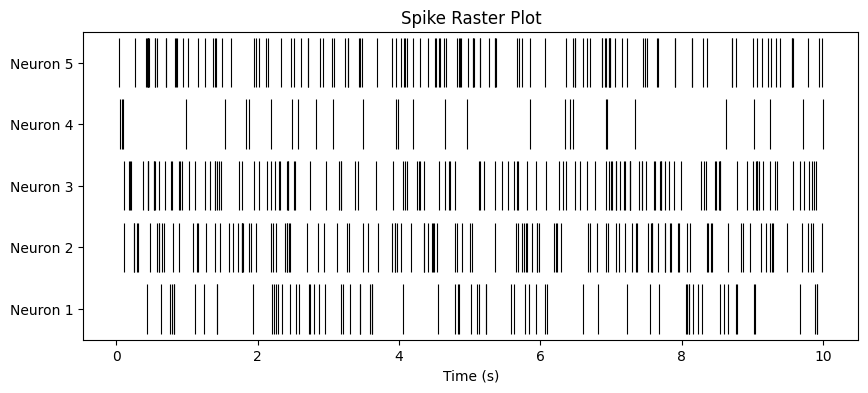

In [3]:
visualization.plot_raster(spikes)
plt.show()


## 3. Population firing rate over time

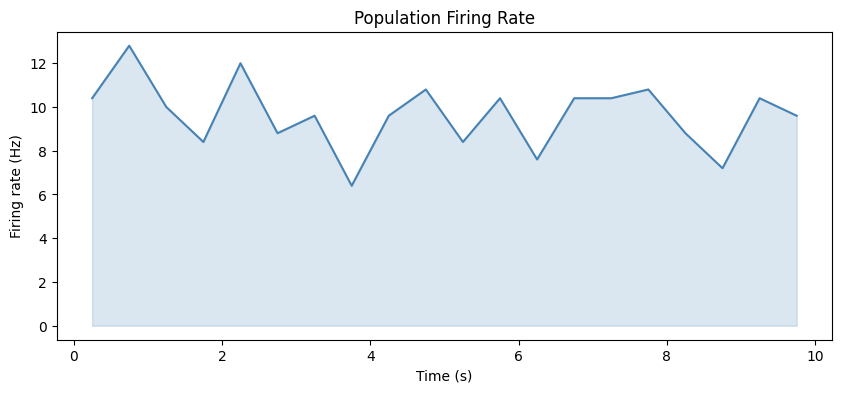

In [4]:
visualization.plot_firing_rate_over_time(spikes, bin_size=0.5)
plt.show()


## 4. Spike count histogram for a single neuron

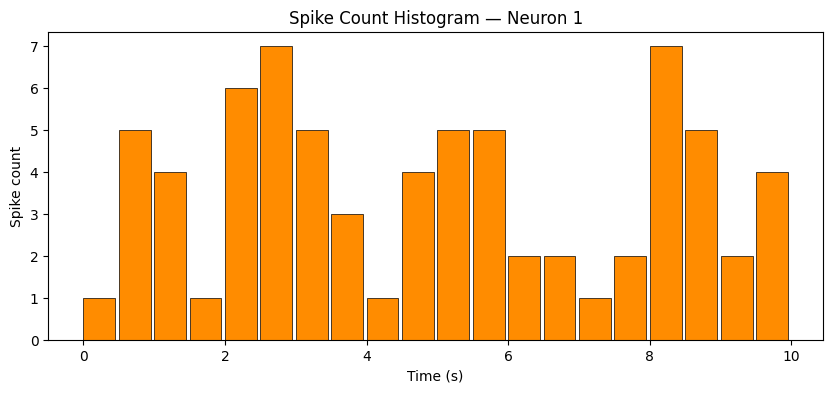

In [5]:
neuron_to_inspect = ids[0]
visualization.plot_spike_histogram(spikes[neuron_to_inspect], bin_size=0.5,
                                    title=f"Spike Count Histogram — Neuron {neuron_to_inspect}")
plt.show()


## 5. Inter-spike interval (ISI) distribution

ISIs reveal firing regularity — tightly clustered ISIs suggest a more regular firing pattern, while a wide spread suggests burstier or more irregular firing.

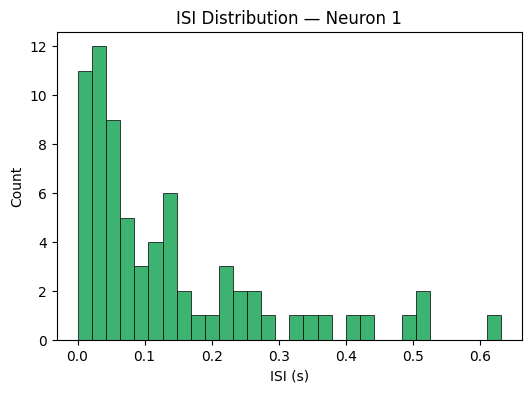

In [6]:
visualization.plot_isi_histogram(spikes[neuron_to_inspect],
                                  title=f"ISI Distribution — Neuron {neuron_to_inspect}")
plt.show()


## 6. Compare average firing rates across neurons

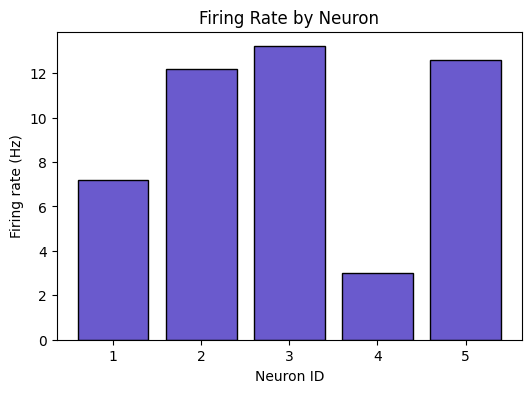

Neuron 1: 7.20 Hz
Neuron 2: 12.20 Hz
Neuron 3: 13.20 Hz
Neuron 4: 3.00 Hz
Neuron 5: 12.60 Hz


In [7]:
visualization.plot_firing_rate_comparison(spikes, duration=duration)
plt.show()

rates = analysis.firing_rates_all(spikes, duration=duration)
for nid, rate in sorted(rates.items()):
    print(f"Neuron {nid}: {rate:.2f} Hz")


## Next steps

- Swap `data/sample_spikes.csv` for your own recordings, or data exported
  from the Allen Brain Atlas / CRCNS (see `data/README.md`).
- Try different `bin_size` values in the firing-rate and histogram plots.
- Extend `src/analysis.py` with new metrics (e.g. Fano factor, CV of ISIs).
